## Color-color box selection

### **LBG Selection via $u$-dropout Technique**

**Objective:** To isolate Lyman Break Galaxies (LBGs) at $z \sim 2$ by identifying the Lyman limit break ($912\text{ \AA}$) as it passes through the $u$-band filter.

**Selection Criteria:** 
We adopt a modified version of the classic $u$-dropout color-box:
*   **Color-Color Box:** $(u-g) > 0.3$, $-0.5 < (g-r) < 1.0$.
*   **Diagonal Cut:** $(u-g) > 2.2(g-r) + 0.32$ OR $[(u-g) > 1.6(g-r) + 0.75 \text{ AND } (u-g) > 0.9]$.
*   **Quality Cuts:** $22.5 < r < 23.75$ and clean photometry flags.

**Results:**
*   **Left Panel:** The color-color distribution demonstrates that high-redshift sources ($z_{\rm phot} \gtrsim 2.5$, yellow/orange) are effectively isolated within the defined blue boundary, well-separated from the low-redshift foreground (purple).
*   **Right Panel:** The redshift histogram of the selected sample shows a robust peak at $z \approx 2.8$. The selection yields **2,028 candidates** with a high-redshift purity of **78.9%** ($z > 2$). Minor contamination at $z < 0.5$ is noted, likely due to the "red-galaxy" color degeneracy.

Total sources: 5,263,013
After base cuts: 132,955
Selected by color-color box: 2,028


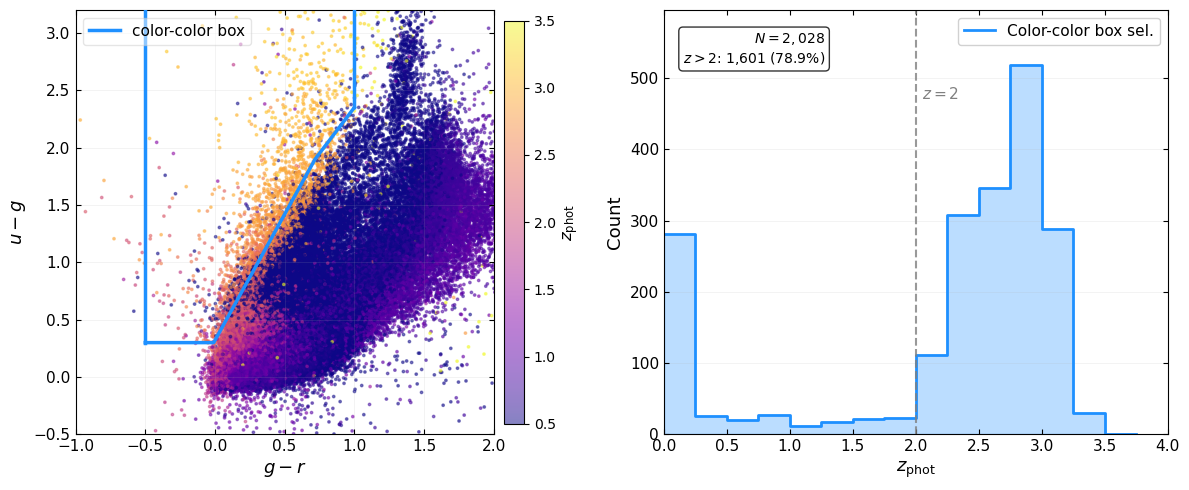

✓ Figure saved: ../images/cosmos_lbg_color_selection.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table

# =============================================================================
# Load COSMOS catalog
# =============================================================================
path_cosmos = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab = Table.read(path_cosmos, hdu=1)

# Extract columns
g = np.array(tab['g'], dtype=float)
r = np.array(tab['r'], dtype=float)
u = np.array(tab['u'], dtype=float)
u_err = np.array(tab['u_err'], dtype=float)
zphot = np.array(tab['ZPHOT'], dtype=float)
z_best = np.array(tab['Z_BEST'], dtype=float)
mask_flag = np.array(tab['MASK'])
flag_field = np.array(tab['FLAG_FIELD_BINARY'])
obj_type = np.array(tab['OBJ_TYPE'])

# Compute colors
g_r = g - r
u_g = u - g

# =============================================================================
# Selection criteria (common)
# =============================================================================
# Base selection: r-band cut, u_err cut, valid photometry, field flags
mask_base = (
    np.isfinite(g_r) & np.isfinite(u_g) &
    np.isfinite(zphot) & (zphot != -99) &
    np.isfinite(z_best) & (z_best != -99) &
    (r > 22.5) & (r < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

# Color-color box selection (u-dropout criteria)
cond_ug = u_g > 0.3
cond_gr = (g_r > -0.5) & (g_r < 1.0)
cond_diag = (u_g > (2.2*g_r + 0.32)) | ((u_g > (1.6*g_r + 0.75)) & (u_g > 0.9))

mask_box = mask_base & cond_ug & cond_gr & cond_diag

# Extract selected data
g_r_sel = g_r[mask_base]
u_g_sel = u_g[mask_base]
zphot_sel = zphot[mask_base]
z_box = zphot[mask_box]

print(f"Total sources: {len(tab):,}")
print(f"After base cuts: {mask_base.sum():,}")
print(f"Selected by color-color box: {mask_box. sum():,}")

# =============================================================================
# Compute color-cut boundary
# =============================================================================
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([
    max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
    for gr in g_r_line
])

# =============================================================================
# Create publication-quality figure (two panels, side by side)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# Left panel: Color-color diagram
# -----------------------------------------------------------------------------
ax1 = axes[0]

# Scatter plot with photo-z coloring
cmap = 'plasma'
norm = colors.Normalize(vmin=0.5, vmax=3.5)
sc = ax1.scatter(
    g_r_sel, u_g_sel, c=zphot_sel,
    cmap=cmap, norm=norm,
    s=3, alpha=0.5, rasterized=True
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax1, pad=0.02, shrink=0.95)
cbar.set_label(r'$z_{\rm phot}$', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Color-cut boundary (blue polygon)
ax1.plot(g_r_line, lower_bound, color='dodgerblue', lw=2.5, 
         label='color-color box', zorder=5)
ax1.plot([-0.5, -0.5], [lower_bound[0], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([1.0, 1.0], [lower_bound[-1], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([-0.5, 1.0], [3.5, 3.5], color='dodgerblue', lw=2.5, zorder=5)

# Axis settings
ax1.set_xlim(-1.0, 2.0)
ax1.set_ylim(-0.5, 3.2)
ax1.set_xlabel(r'$g - r$', fontsize=13)
ax1.set_ylabel(r'$u - g$', fontsize=13)
ax1.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.5)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# -----------------------------------------------------------------------------
# Right panel: Photo-z histogram of selected LBGs
# -----------------------------------------------------------------------------
ax2 = axes[1]

# Histogram settings
bins = np.arange(0, 4.25, 0.25)  # 0 to 4, step 0.25
counts, bin_edges = np.histogram(z_box, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Step histogram
ax2.step(bin_edges[:-1], counts, where='post', color='dodgerblue', lw=2, 
         label='Color-color box sel.')
ax2.fill_between(bin_edges[:-1], counts, step='post', alpha=0.3, color='dodgerblue')

# Reference line at z = 2 (LBG threshold)
ax2.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax2.text(2.05, ax2.get_ylim()[1]*0.9 if counts.max() > 0 else 10, 
         r'$z=2$', fontsize=11, color='gray', va='top')

# Axis settings
ax2.set_xlim(0, 4.0)
ax2.set_ylim(0, counts.max() * 1.15 if counts.max() > 0 else 10)
ax2.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax2.set_ylabel('Count', fontsize=13)
ax2.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')

# Statistics annotation
n_total = mask_box.sum()
n_z_gt_2 = np.sum(z_box > 2)
frac_z_gt_2 = n_z_gt_2 / n_total * 100 if n_total > 0 else 0
stats_text = (f'$N = {n_total:,}$\n'
              f'$z > 2$: {n_z_gt_2:,} ({frac_z_gt_2:.1f}%)')
ax2.text(0.32, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# -----------------------------------------------------------------------------
# Final layout
# -----------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('../images/cosmos_lbg_color_selection.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: ../images/cosmos_lbg_color_selection.png")

## Training Data Building

### Cross matching Photometric and Spectroscopic Catalogs

In [4]:
import numpy as np
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as unit

# =============================================================================
# Load catalogs
# =============================================================================
print("=" * 70)
print("LOADING CATALOGS")
print("=" * 70)

# COSMOS photometric catalog
path_phot = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab_phot = Table.read(path_phot, hdu=1)
print(f"Photometric catalog:  {len(tab_phot):,} sources")

# DESI spectroscopic catalog
path_spec = "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits"
tab_spec = Table.read(path_spec, hdu=1)
print(f"Spectroscopic catalog: {len(tab_spec):,} sources")

# =============================================================================
# Apply base selection to photometric catalog (same as before)
# =============================================================================
print("\n" + "=" * 70)
print("APPLYING BASE SELECTION TO PHOTOMETRIC CATALOG")
print("=" * 70)

# Extract columns
g = np.array(tab_phot['g'], dtype=float)
r = np.array(tab_phot['r'], dtype=float)
u = np.array(tab_phot['u'], dtype=float)
u_err = np.array(tab_phot['u_err'], dtype=float)
zphot = np.array(tab_phot['ZPHOT'], dtype=float)
z_best = np.array(tab_phot['Z_BEST'], dtype=float)
mask_flag = np.array(tab_phot['MASK'])
flag_field = np.array(tab_phot['FLAG_FIELD_BINARY'])
obj_type = np.array(tab_phot['OBJ_TYPE'])

# Compute colors
g_r = g - r
u_g = u - g

# Base selection mask
mask_base = (
    np.isfinite(g_r) & np.isfinite(u_g) &
    np.isfinite(zphot) & (zphot != -99) &
    np.isfinite(z_best) & (z_best != -99) &
    (r > 22.5) & (r < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

n_base = mask_base.sum()
print(f"Total photometric sources: {len(tab_phot):,}")
print(f"After base cuts: {n_base:,}")

# Get indices of selected sources
idx_phot_base = np.where(mask_base)[0]

# =============================================================================
# Coordinate matching
# =============================================================================
print("\n" + "=" * 70)
print("COORDINATE MATCHING")
print("=" * 70)

# Match radius
MATCH_RADIUS_ARCSEC = 1.0

# Photometric coordinates (base-selected)
ra_phot = np.array(tab_phot['RA'], dtype=float)[mask_base]
dec_phot = np.array(tab_phot['DEC'], dtype=float)[mask_base]
coords_phot = SkyCoord(ra=ra_phot * unit.deg, dec=dec_phot * unit.deg)

# Spectroscopic coordinates
ra_spec = np.array(tab_spec['TARGET_RA'], dtype=float)
dec_spec = np.array(tab_spec['TARGET_DEC'], dtype=float)
coords_spec = SkyCoord(ra=ra_spec * unit.deg, dec=dec_spec * unit.deg)

print(f"Photometric (base-selected): {len(coords_phot):,} sources")
print(f"Spectroscopic: {len(coords_spec):,} sources")
print(f"Match radius: {MATCH_RADIUS_ARCSEC} arcsec")

# -----------------------------------------------------------------------------
# Match 1: Photometric -> Spectroscopic (for each phot source, find nearest spec)
# -----------------------------------------------------------------------------
print("\n[1] Matching:  Photometric -> Spectroscopic")
idx_spec_match, sep_phot2spec, _ = match_coordinates_sky(coords_phot, coords_spec)
good_match_phot2spec = sep_phot2spec.arcsec < MATCH_RADIUS_ARCSEC

n_phot_matched = good_match_phot2spec.sum()
print(f"    Phot sources with spec match: {n_phot_matched:,} ({n_phot_matched/len(coords_phot)*100:.2f}%)")

# -----------------------------------------------------------------------------
# Match 2: Spectroscopic -> Photometric (for each spec source, find nearest phot)
# -----------------------------------------------------------------------------
print("\n[2] Matching:  Spectroscopic -> Photometric")
idx_phot_match, sep_spec2phot, _ = match_coordinates_sky(coords_spec, coords_phot)
good_match_spec2phot = sep_spec2phot.arcsec < MATCH_RADIUS_ARCSEC

n_spec_matched = good_match_spec2phot.sum()
print(f"    Spec sources with phot match: {n_spec_matched:,} ({n_spec_matched/len(coords_spec)*100:.2f}%)")

# =============================================================================
# Create masks for matched sources
# =============================================================================
print("\n" + "=" * 70)
print("CREATING MATCHED MASKS")
print("=" * 70)

# Mask for photometric catalog (base-selected, length = n_base)
# True if this phot source has a spec match within radius
mask_phot_matched = good_match_phot2spec  # length = n_base

# Mask for spectroscopic catalog (full, length = len(tab_spec))
# True if this spec source has a phot match within radius
mask_spec_matched = good_match_spec2phot  # length = len(tab_spec)

# Full photometric mask (length = len(tab_phot))
# True if source passes base cuts AND has spec match
mask_phot_full = np.zeros(len(tab_phot), dtype=bool)
mask_phot_full[idx_phot_base[mask_phot_matched]] = True

print(f"Photometric matched mask (base-selected): {mask_phot_matched.sum():,} / {len(mask_phot_matched):,}")
print(f"Spectroscopic matched mask:  {mask_spec_matched.sum():,} / {len(mask_spec_matched):,}")
print(f"Photometric matched mask (full catalog): {mask_phot_full.sum():,} / {len(tab_phot):,}")

# =============================================================================
# Get matched indices (for cross-referencing)
# =============================================================================
# For each matched phot source, the corresponding spec index
phot_to_spec_idx = idx_spec_match[mask_phot_matched]

# For each matched spec source, the corresponding phot index (within base-selected)
spec_to_phot_idx_base = idx_phot_match[mask_spec_matched]
# Convert to full photometric catalog index
spec_to_phot_idx_full = idx_phot_base[spec_to_phot_idx_base]

# =============================================================================
# Summary statistics
# =============================================================================
print("\n" + "=" * 70)
print("MATCHING SUMMARY")
print("=" * 70)

print(f"""
CATALOGS: 
  Photometric (total):         {len(tab_phot):,}
  Photometric (base-selected): {n_base:,}
  Spectroscopic (total):       {len(tab_spec):,}

MATCHING RESULTS (radius = {MATCH_RADIUS_ARCSEC} arcsec):
  Phot (base) with spec match: {n_phot_matched:,} ({n_phot_matched/n_base*100:.2f}% of base-selected)
  Spec with phot (base) match: {n_spec_matched:,} ({n_spec_matched/len(tab_spec)*100:.2f}% of spec catalog)

SEPARATION STATISTICS (matched sources):
  Phot->Spec: median = {np.median(sep_phot2spec[good_match_phot2spec].arcsec):.3f} arcsec
  Spec->Phot:  median = {np.median(sep_spec2phot[good_match_spec2phot].arcsec):.3f} arcsec
""")

# =============================================================================
# Return masks for further use
# =============================================================================
print("\n" + "=" * 70)
print("OUTPUT MASKS")
print("=" * 70)

print(f"""
Available masks for further analysis: 

1. mask_phot_matched (length = {len(mask_phot_matched):,})
   - Boolean mask for base-selected photometric sources
   - True if matched to spectroscopic catalog
   - Use:  tab_phot[mask_base][mask_phot_matched]

2. mask_spec_matched (length = {len(mask_spec_matched):,})
   - Boolean mask for spectroscopic catalog
   - True if matched to base-selected photometric sources
   - Use: tab_spec[mask_spec_matched]

3. mask_phot_full (length = {len(mask_phot_full):,})
   - Boolean mask for full photometric catalog
   - True if passes base cuts AND matched to spec
   - Use: tab_phot[mask_phot_full]

4. phot_to_spec_idx (length = {len(phot_to_spec_idx):,})
   - For each matched phot source, the index in spec catalog
   
5. spec_to_phot_idx_full (length = {len(spec_to_phot_idx_full):,})
   - For each matched spec source, the index in full phot catalog
""")

# =============================================================================
# Quick validation: show a few matched pairs
# =============================================================================
print("=" * 70)
print("SAMPLE MATCHED PAIRS (first 10)")
print("=" * 70)

n_show = min(10, n_phot_matched)
print(f"\n{'Phot_RA':>12} {'Phot_Dec':>12} {'Spec_RA':>12} {'Spec_Dec':>12} {'Sep(arcsec)':>12}")
print("-" * 65)

matched_phot_idx = np.where(mask_phot_matched)[0][: n_show]
for i in matched_phot_idx:
    spec_idx = idx_spec_match[i]
    sep = sep_phot2spec[i]. arcsec
    print(f"{ra_phot[i]:12.6f} {dec_phot[i]:12.6f} {ra_spec[spec_idx]: 12.6f} {dec_spec[spec_idx]:12.6f} {sep: 12.4f}")

LOADING CATALOGS
Photometric catalog:  5,263,013 sources
Spectroscopic catalog: 4,486 sources

APPLYING BASE SELECTION TO PHOTOMETRIC CATALOG
Total photometric sources: 5,263,013
After base cuts: 132,955

COORDINATE MATCHING
Photometric (base-selected): 132,955 sources
Spectroscopic: 4,486 sources
Match radius: 1.0 arcsec

[1] Matching:  Photometric -> Spectroscopic
    Phot sources with spec match: 1,519 (1.14%)

[2] Matching:  Spectroscopic -> Photometric
    Spec sources with phot match: 1,949 (43.45%)

CREATING MATCHED MASKS
Photometric matched mask (base-selected): 1,519 / 132,955
Spectroscopic matched mask:  1,949 / 4,486
Photometric matched mask (full catalog): 1,519 / 5,263,013

MATCHING SUMMARY

CATALOGS: 
  Photometric (total):         5,263,013
  Photometric (base-selected): 132,955
  Spectroscopic (total):       4,486

MATCHING RESULTS (radius = 1.0 arcsec):
  Phot (base) with spec match: 1,519 (1.14% of base-selected)
  Spec with phot (base) match: 1,949 (43.45% of spec ca

In [5]:
# =============================================================================
# Unique matching (one-to-one)
# =============================================================================
print("\n" + "=" * 70)
print("UNIQUE (ONE-TO-ONE) MATCHING ANALYSIS")
print("=" * 70)

# Method 1: Find unique spec indices matched from phot
spec_idx_matched_from_phot = idx_spec_match[mask_phot_matched]
unique_spec_idx, counts_spec = np.unique(spec_idx_matched_from_phot, return_counts=True)
n_unique_spec = len(unique_spec_idx)
n_multi_match_spec = np.sum(counts_spec > 1)

print(f"\n[1] From Phot→Spec matching:")
print(f"    Total matches: {mask_phot_matched.sum():,}")
print(f"    Unique spec sources matched: {n_unique_spec: ,}")
print(f"    Spec sources with multiple phot matches: {n_multi_match_spec:,}")

# Method 2: Find unique phot indices matched from spec
phot_idx_matched_from_spec = idx_phot_match[mask_spec_matched]
unique_phot_idx, counts_phot = np.unique(phot_idx_matched_from_spec, return_counts=True)
n_unique_phot = len(unique_phot_idx)
n_multi_match_phot = np.sum(counts_phot > 1)

print(f"\n[2] From Spec→Phot matching:")
print(f"    Total matches: {mask_spec_matched.sum():,}")
print(f"    Unique phot sources matched: {n_unique_phot:,}")
print(f"    Phot sources with multiple spec matches: {n_multi_match_phot:,}")

# =============================================================================
# Create strict one-to-one matching
# =============================================================================
# Keep only pairs where both directions agree (mutual nearest neighbors)

print(f"\n[3] Mutual nearest neighbor (strict one-to-one):")

# For a pair to be mutual: 
# - Phot[i] matches to Spec[j]  (idx_spec_match[i] = j)
# - Spec[j] matches back to Phot[i]  (idx_phot_match[j] = i)

mutual_mask_phot = np.zeros(len(mask_phot_matched), dtype=bool)

for i in range(len(mask_phot_matched)):
    if mask_phot_matched[i]:   # phot[i] has a spec match
        j = idx_spec_match[i]  # the matched spec index
        if mask_spec_matched[j]:  # spec[j] also has a phot match
            k = idx_phot_match[j]  # the phot index that spec[j] matches to
            if k == i:  # mutual match! 
                mutual_mask_phot[i] = True

n_mutual = mutual_mask_phot.sum()
print(f"    Mutual (one-to-one) matches: {n_mutual:,}")

# Create corresponding mask for spec catalog
mutual_spec_idx = idx_spec_match[mutual_mask_phot]
mutual_mask_spec = np.zeros(len(tab_spec), dtype=bool)
mutual_mask_spec[mutual_spec_idx] = True

print(f"\n[4] Final one-to-one masks:")
print(f"    mutual_mask_phot (base-selected): {mutual_mask_phot.sum():,}")
print(f"    mutual_mask_spec:  {mutual_mask_spec.sum():,}")


UNIQUE (ONE-TO-ONE) MATCHING ANALYSIS

[1] From Phot→Spec matching:
    Total matches: 1,519
    Unique spec sources matched:  1,511
    Spec sources with multiple phot matches: 7

[2] From Spec→Phot matching:
    Total matches: 1,949
    Unique phot sources matched: 1,511
    Phot sources with multiple spec matches: 438

[3] Mutual nearest neighbor (strict one-to-one):
    Mutual (one-to-one) matches: 1,511

[4] Final one-to-one masks:
    mutual_mask_phot (base-selected): 1,511
    mutual_mask_spec:  1,511


### Data Quality: CHI, ZPHOT and ZML_low&high.

DATA EXPLORATION FOR TRAINING SET DESIGN

Total base-selected:  132,955
  With spec match (mutual): 1,511
  Without spec match: 131,444

Photo-z based LBG (ZPHOT > 2):
  Total LBG: 7,408 (5.6%)
  Total non-LBG: 125,547

[1] CHI_BEST DISTRIBUTION
Valid CHI_BEST: 132,955 (100.0%)
  Min:  0.04
  Max:  2986.20
  Median: 5.22
  Percentiles: 10%=2.46, 50%=5.22, 90%=12.40

  LBG (z>2): median CHI_BEST = 9.19, N = 7,408
  Non-LBG:    median CHI_BEST = 5.01, N = 125,547

[2] PHOTO-Z UNCERTAINTY DISTRIBUTION
Valid z_err: 132,307
  Relative error (sigma_z / z_phot):
    Median: 0.052
    Percentiles: 10%=0.028, 50%=0.052, 90%=0.161

  LBG:  median rel_err = 0.039, N = 7,383
  Non-LBG: median rel_err = 0.052, N = 124,924

[3] SPEC-MATCHED vs NON-MATCHED COMPARISON

Spec-matched (1,511 sources):
  LBG (by ZPHOT): 1,213 (80.3%)
  Median CHI_BEST: 11.88

Non-spec (131,444 sources):
  LBG (by ZPHOT): 6,195 (4.7%)
  Median CHI_BEST: 5.18


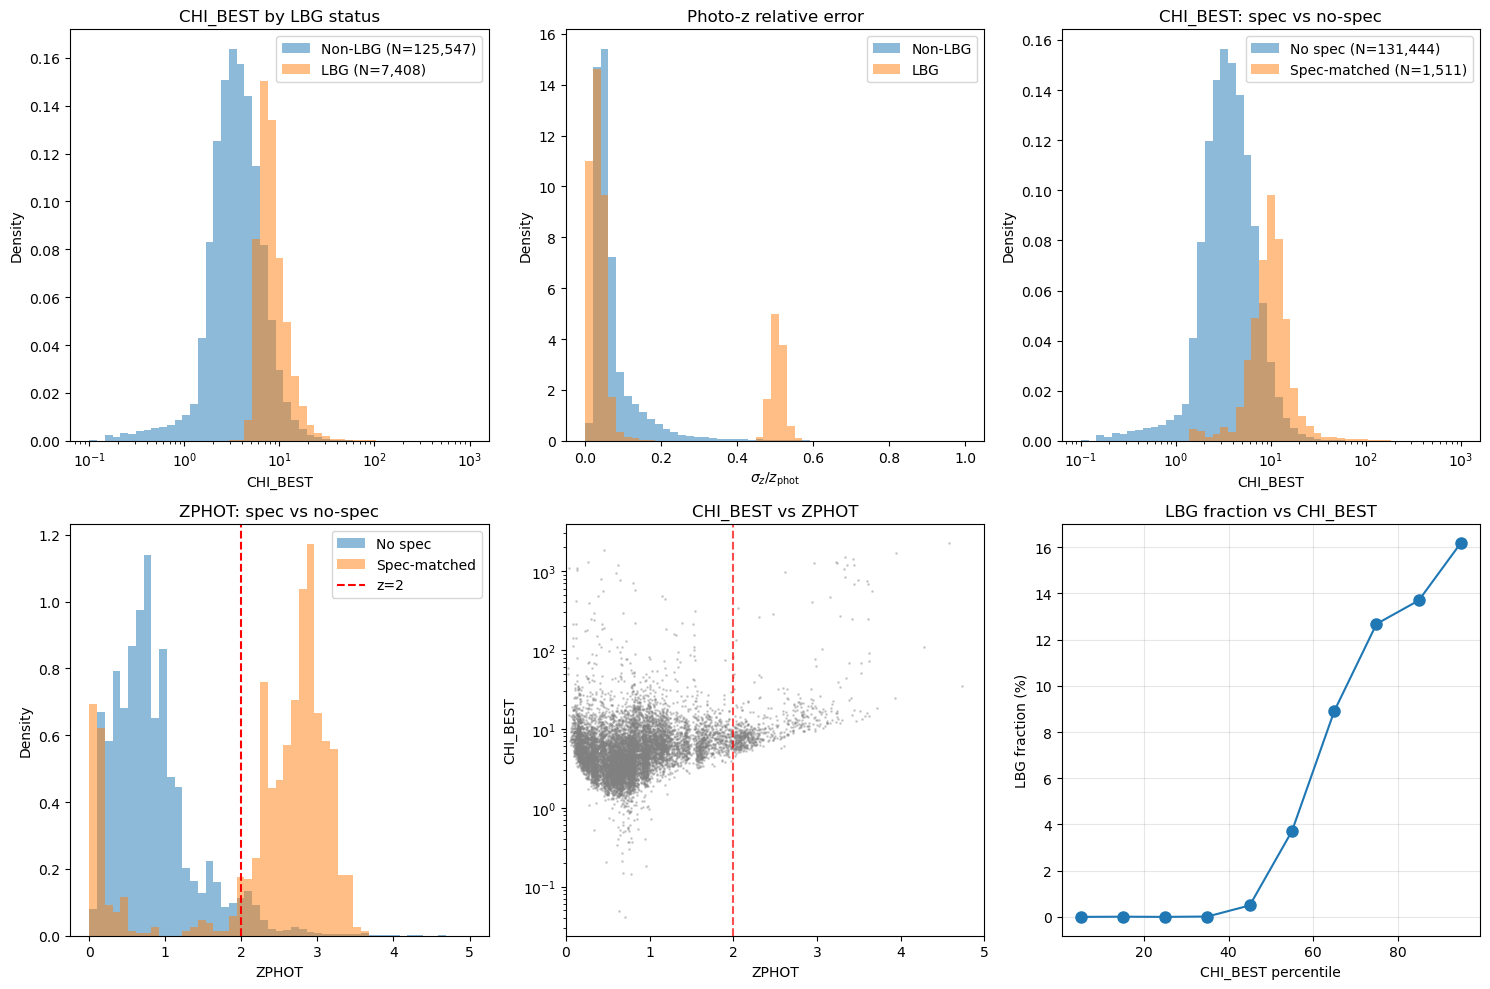


[4] CHI_BEST THRESHOLD ANALYSIS

 Threshold   N_selected      N_LBG   LBG_frac   N_nonLBG
-------------------------------------------------------
         5       62,609         31       0.0%     62,578
        10      111,829      3,912       3.5%    107,917
        20      126,426      5,463       4.3%    120,963
        50      129,738      5,761       4.4%    123,977
       100      130,375      5,838       4.5%    124,537


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# =============================================================================
# Load data and apply masks
# =============================================================================

# Get base-selected photometric data
tab_phot_base = tab_phot[mask_base]

# Extract relevant columns
zphot_base = np.array(tab_phot_base['ZPHOT'], dtype=float)
chi_best_base = np.array(tab_phot_base['CHI_BEST'], dtype=float)
z_ml68_low = np.array(tab_phot_base['Z_ML68_LOW'], dtype=float)
z_ml68_high = np. array(tab_phot_base['Z_ML68_HIGH'], dtype=float)

# Compute photo-z uncertainty (relative)
z_ml68_err = (z_ml68_high - z_ml68_low) / 2
z_ml68_rel_err = z_ml68_err / np.maximum(zphot_base, 0.01)  # relative error

# Define LBG by photo-z
is_lbg_photoz = zphot_base > 2.0

print("=" * 70)
print("DATA EXPLORATION FOR TRAINING SET DESIGN")
print("=" * 70)

print(f"\nTotal base-selected:  {len(tab_phot_base):,}")
print(f"  With spec match (mutual): {mutual_mask_phot.sum():,}")
print(f"  Without spec match: {(~mutual_mask_phot).sum():,}")

print(f"\nPhoto-z based LBG (ZPHOT > 2):")
print(f"  Total LBG: {is_lbg_photoz.sum():,} ({is_lbg_photoz.mean()*100:.1f}%)")
print(f"  Total non-LBG: {(~is_lbg_photoz).sum():,}")

# =============================================================================
# 1. Check CHI_BEST distribution
# =============================================================================
print("\n" + "=" * 70)
print("[1] CHI_BEST DISTRIBUTION")
print("=" * 70)

# Valid CHI_BEST
valid_chi = np.isfinite(chi_best_base) & (chi_best_base > 0) & (chi_best_base < 1e10)
print(f"Valid CHI_BEST: {valid_chi.sum():,} ({valid_chi.mean()*100:.1f}%)")

chi_valid = chi_best_base[valid_chi]
print(f"  Min:  {chi_valid.min():.2f}")
print(f"  Max:  {chi_valid.max():.2f}")
print(f"  Median: {np.median(chi_valid):.2f}")
print(f"  Percentiles: 10%={np.percentile(chi_valid, 10):.2f}, "
      f"50%={np.percentile(chi_valid, 50):.2f}, "
      f"90%={np.percentile(chi_valid, 90):.2f}")

# CHI_BEST by LBG status
chi_lbg = chi_best_base[valid_chi & is_lbg_photoz]
chi_nonlbg = chi_best_base[valid_chi & ~is_lbg_photoz]

print(f"\n  LBG (z>2): median CHI_BEST = {np. median(chi_lbg):.2f}, N = {len(chi_lbg):,}")
print(f"  Non-LBG:    median CHI_BEST = {np.median(chi_nonlbg):.2f}, N = {len(chi_nonlbg):,}")

# =============================================================================
# 2. Check photo-z uncertainty distribution
# =============================================================================
print("\n" + "=" * 70)
print("[2] PHOTO-Z UNCERTAINTY DISTRIBUTION")
print("=" * 70)

valid_zerr = np.isfinite(z_ml68_rel_err) & (z_ml68_rel_err > 0) & (z_ml68_rel_err < 10)
print(f"Valid z_err: {valid_zerr.sum():,}")

zerr_valid = z_ml68_rel_err[valid_zerr]
print(f"  Relative error (sigma_z / z_phot):")
print(f"    Median: {np.median(zerr_valid):.3f}")
print(f"    Percentiles: 10%={np.percentile(zerr_valid, 10):.3f}, "
      f"50%={np.percentile(zerr_valid, 50):.3f}, "
      f"90%={np.percentile(zerr_valid, 90):.3f}")

# By LBG status
zerr_lbg = z_ml68_rel_err[valid_zerr & is_lbg_photoz]
zerr_nonlbg = z_ml68_rel_err[valid_zerr & ~is_lbg_photoz]

print(f"\n  LBG:  median rel_err = {np.median(zerr_lbg):.3f}, N = {len(zerr_lbg):,}")
print(f"  Non-LBG: median rel_err = {np.median(zerr_nonlbg):.3f}, N = {len(zerr_nonlbg):,}")

# =============================================================================
# 3. Compare spec-matched vs non-matched
# =============================================================================
print("\n" + "=" * 70)
print("[3] SPEC-MATCHED vs NON-MATCHED COMPARISON")
print("=" * 70)

# Spec-matched sources
chi_spec = chi_best_base[mutual_mask_phot & valid_chi]
zphot_spec = zphot_base[mutual_mask_phot]
is_lbg_spec = zphot_spec > 2

# Non-spec sources
chi_nospec = chi_best_base[~mutual_mask_phot & valid_chi]
zphot_nospec = zphot_base[~mutual_mask_phot]
is_lbg_nospec = zphot_nospec > 2

print(f"\nSpec-matched ({mutual_mask_phot.sum():,} sources):")
print(f"  LBG (by ZPHOT): {is_lbg_spec.sum():,} ({is_lbg_spec.mean()*100:.1f}%)")
print(f"  Median CHI_BEST: {np.median(chi_spec):.2f}")

print(f"\nNon-spec ({(~mutual_mask_phot).sum():,} sources):")
print(f"  LBG (by ZPHOT): {is_lbg_nospec.sum():,} ({is_lbg_nospec.mean()*100:.1f}%)")
print(f"  Median CHI_BEST: {np.median(chi_nospec):.2f}")

# =============================================================================
# 4. Visualizations
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# (a) CHI_BEST distribution by LBG status
ax = axes[0, 0]
bins_chi = np.logspace(-1, 3, 50)
ax.hist(chi_nonlbg, bins=bins_chi, alpha=0.5, label=f'Non-LBG (N={len(chi_nonlbg):,})', density=True)
ax.hist(chi_lbg, bins=bins_chi, alpha=0.5, label=f'LBG (N={len(chi_lbg):,})', density=True)
ax.set_xscale('log')
ax.set_xlabel('CHI_BEST')
ax.set_ylabel('Density')
ax.set_title('CHI_BEST by LBG status')
ax.legend()

# (b) Photo-z relative error by LBG status
ax = axes[0, 1]
bins_err = np.linspace(0, 1, 50)
ax.hist(zerr_nonlbg[zerr_nonlbg < 1], bins=bins_err, alpha=0.5, label='Non-LBG', density=True)
ax.hist(zerr_lbg[zerr_lbg < 1], bins=bins_err, alpha=0.5, label='LBG', density=True)
ax.set_xlabel(r'$\sigma_z / z_{\rm phot}$')
ax.set_ylabel('Density')
ax.set_title('Photo-z relative error')
ax.legend()

# (c) CHI_BEST:  spec-matched vs non-matched
ax = axes[0, 2]
ax.hist(chi_nospec, bins=bins_chi, alpha=0.5, label=f'No spec (N={len(chi_nospec):,})', density=True)
ax.hist(chi_spec, bins=bins_chi, alpha=0.5, label=f'Spec-matched (N={len(chi_spec):,})', density=True)
ax.set_xscale('log')
ax.set_xlabel('CHI_BEST')
ax.set_ylabel('Density')
ax.set_title('CHI_BEST: spec vs no-spec')
ax.legend()

# (d) ZPHOT distribution by spec match
ax = axes[1, 0]
bins_z = np.linspace(0, 5, 50)
ax.hist(zphot_nospec[(zphot_nospec > 0) & (zphot_nospec < 5)], bins=bins_z, 
        alpha=0.5, label='No spec', density=True)
ax.hist(zphot_spec[(zphot_spec > 0) & (zphot_spec < 5)], bins=bins_z, 
        alpha=0.5, label='Spec-matched', density=True)
ax.axvline(2.0, color='red', linestyle='--', label='z=2')
ax.set_xlabel('ZPHOT')
ax.set_ylabel('Density')
ax.set_title('ZPHOT: spec vs no-spec')
ax.legend()

# (e) CHI_BEST vs ZPHOT scatter
ax = axes[1, 1]
sample_idx = np.random.choice(len(chi_best_base[valid_chi]), 
                               min(10000, valid_chi.sum()), replace=False)
ax.scatter(zphot_base[valid_chi][sample_idx], chi_best_base[valid_chi][sample_idx],
           s=1, alpha=0.3, c='gray')
ax.axvline(2.0, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('ZPHOT')
ax.set_ylabel('CHI_BEST')
ax.set_yscale('log')
ax.set_xlim(0, 5)
ax.set_title('CHI_BEST vs ZPHOT')

# (f) LBG fraction vs CHI_BEST percentile
ax = axes[1, 2]
chi_percentiles = np.percentile(chi_valid, np.arange(0, 101, 10))
lbg_fracs = []
for i in range(len(chi_percentiles) - 1):
    mask_bin = valid_chi & (chi_best_base >= chi_percentiles[i]) & (chi_best_base < chi_percentiles[i+1])
    if mask_bin.sum() > 0:
        lbg_frac = is_lbg_photoz[mask_bin].mean()
    else:
        lbg_frac = np.nan
    lbg_fracs.append(lbg_frac)
    
bin_centers = [(chi_percentiles[i] + chi_percentiles[i+1])/2 for i in range(len(chi_percentiles)-1)]
ax.plot(range(5, 100, 10), [f*100 for f in lbg_fracs], 'o-', markersize=8)
ax.set_xlabel('CHI_BEST percentile')
ax.set_ylabel('LBG fraction (%)')
ax.set_title('LBG fraction vs CHI_BEST')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/training_set_exploration.png', dpi=600, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. Suggested CHI_BEST threshold analysis
# =============================================================================
print("\n" + "=" * 70)
print("[4] CHI_BEST THRESHOLD ANALYSIS")
print("=" * 70)

thresholds = [5, 10, 20, 50, 100]

print(f"\n{'Threshold': >10} {'N_selected':>12} {'N_LBG':>10} {'LBG_frac':>10} {'N_nonLBG':>10}")
print("-" * 55)

for thresh in thresholds:
    mask_low_chi = valid_chi & (chi_best_base < thresh) & ~mutual_mask_phot
    n_sel = mask_low_chi.sum()
    n_lbg = (mask_low_chi & is_lbg_photoz).sum()
    n_nonlbg = (mask_low_chi & ~is_lbg_photoz).sum()
    lbg_frac = n_lbg / n_sel * 100 if n_sel > 0 else 0
    
    print(f"{thresh:>10} {n_sel:>12,} {n_lbg: >10,} {lbg_frac:>9.1f}% {n_nonlbg:>10,}")